# 01 — Data Inspection and Exploratory Data Analysis

This notebook performs the data-integrity and exploratory analysis directly from the source CSV.

It covers:

- source-data structure and target balance;
- conventional missing values and explicit `unknown` categories;
- exact duplicates and pseudo-repeat-profile sensitivity;
- numeric and categorical summaries;
- contiguous ordered month-labelled blocks;
- pre-call Pearson and bias-corrected Cramér's V associations;
- a separate post-call `duration` leakage diagnostic;
- pre-call numeric inter-feature correlations;
- the exploratory higher-conversion customer population.

`duration` is deliberately excluded from the deployable/pre-call association set because it is only known after a call. Its association with subscription is reported separately as a leakage diagnostic. All values are calculated from the source CSV during execution.
This clean rerun version has no dependency on `data/`, `results/`, or `figures/` folders and does not write CSV/PNG artifacts during execution.


## 1. Setup and reusable analysis functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, norm
from IPython.display import display

DATA_SOURCE='term-deposit-marketing-2020-labelled.csv'

TARGET='y'
PROFILE=['age','job','marital','education','balance']

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)


def wilson(s,n,conf=.95):
    if n==0:
        return np.nan,np.nan
    z=norm.ppf(1-(1-conf)/2)
    p=s/n
    d=1+z*z/n
    c=p+z*z/(2*n)
    a=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))
    return (c-a)/d,(c+a)/d

def cramer(x,y):
    t=pd.crosstab(x,y)
    n=t.to_numpy().sum()
    if t.empty or n<=1:
        return np.nan
    chi=chi2_contingency(t,correction=False)[0]
    r,k=t.shape
    phi=chi/n
    pc=max(0,phi-((k-1)*(r-1))/(n-1))
    rc=r-((r-1)**2)/(n-1)
    kc=k-((k-1)**2)/(n-1)
    d=min(rc-1,kc-1)
    return np.sqrt(pc/d) if d>0 else 0.

def assoc_num(d,fs):
    z=d[fs].corrwith(d.y_binary).rename('association').reset_index().rename(columns={'index':'feature'})
    z['variable_type']='numeric'
    z['measure']='Pearson r'
    z['association_strength']=z.association.abs()
    return z.sort_values('association_strength',ascending=False).reset_index(drop=True)

def assoc_cat(d,fs):
    z=pd.DataFrame({'feature':fs,'association':[cramer(d[f],d[TARGET]) for f in fs]})
    z['variable_type']='categorical'
    z['measure']="Cramer's V"
    z['association_strength']=z.association
    return z.sort_values('association_strength',ascending=False).reset_index(drop=True)

def conv(d,f):
    z=d.groupby(f,dropna=False).y_binary.agg(customers='size',subscribers='sum').reset_index()
    z['subscription_rate']=z.subscribers/z.customers
    ci=z.apply(lambda r:wilson(int(r.subscribers),int(r.customers)),axis=1)
    z[['ci_lower','ci_upper']]=pd.DataFrame(ci.tolist(),index=z.index)
    return z.sort_values('subscription_rate',ascending=False).reset_index(drop=True)

def blocks(d):
    z=d.copy()
    z['row_order']=np.arange(len(z))
    z['period_id']=z.month.astype(str).ne(z.month.astype(str).shift()).cumsum()
    r=z.groupby('period_id').agg(
        month=('month','first'),
        start_row=('row_order','min'),
        end_row=('row_order','max'),
        customers=('y_binary','size'),
        subscribers=('y_binary','sum')
    ).reset_index()
    r['subscription_rate']=r.subscribers/r.customers
    return r

## 2. Load the dataset and extract its structure

In [2]:
df=pd.read_csv(DATA_SOURCE)
if 'y_binary' in df.columns:
    df=df.drop(columns='y_binary')
df['y_binary']=df[TARGET].eq('yes').astype(int)

source=[c for c in df.columns if c!='y_binary']
predictors=[c for c in source if c!=TARGET]
numeric=df[predictors].select_dtypes(include=np.number).columns.tolist()
categorical=[c for c in predictors if c not in numeric]

n=len(df)
yes=int(df.y_binary.sum())
rate=df.y_binary.mean()
majority=df[TARGET].value_counts(normalize=True).max()

columns=pd.DataFrame({
    'variable':source,
    'dtype':df[source].dtypes.astype(str).values,
    'unique_values':[df[c].nunique(dropna=False) for c in source]
})

target=df[TARGET].value_counts().rename('count').to_frame()
target['percentage']=100*target['count']/n

dataset_summary=pd.DataFrame({
    'measure':['rows','source_columns','predictors','numeric_predictors','categorical_predictors',
               'subscribers','non_subscribers','subscription_rate','majority_accuracy'],
    'value':[n,len(source),len(predictors),len(numeric),len(categorical),yes,n-yes,rate,majority]
})

display(df[source].head())
display(columns)
display(target.round(2))
display(dataset_summary.round(4))


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


,variable,dtype,unique_values
0,age,int64,70
1,job,object,12
2,marital,object,3
3,education,object,4
4,default,object,2
5,balance,int64,6849
6,housing,object,2
7,loan,object,2
8,contact,object,3
9,day,int64,31


,count,percentage
y,,
no,37104,92.76
yes,2896,7.24


,measure,value
0,rows,40000.0000
1,source_columns,14.0000
2,predictors,13.0000
3,numeric_predictors,5.0000
4,categorical_predictors,8.0000
5,subscribers,2896.0000
6,non_subscribers,37104.0000
7,subscription_rate,0.0724
8,majority_accuracy,0.9276


## 3. Data quality, explicit unknowns and pseudo-repeat sensitivity

In [3]:
missing=df[source].isna().sum().rename('missing_count').to_frame()
missing['missing_percentage']=100*missing.missing_count/n

# Distinguish genuine missing values, blank strings, common text placeholders, and explicit 'unknown'.
obj_cols=df[source].select_dtypes(include='object').columns.tolist()
blank_counts=pd.Series({c: df[c].astype(str).str.strip().eq('').sum() for c in obj_cols}, name='blank_count')
placeholder_tokens={'na','n/a','none','null','nan','missing'}
placeholder_counts=pd.Series({
    c: df[c].astype(str).str.strip().str.lower().isin(placeholder_tokens).sum() for c in obj_cols
}, name='text_placeholder_count')
missing_audit=pd.DataFrame(index=source)
missing_audit['genuine_missing_count']=df[source].isna().sum()
missing_audit['blank_string_count']=blank_counts.reindex(source, fill_value=0)
missing_audit['text_placeholder_count']=placeholder_counts.reindex(source, fill_value=0)
exact_dup=int(df[source].duplicated().sum())

unknown=pd.DataFrame({
    'feature':categorical,
    'unknown_count':[df[f].astype(str).str.strip().str.lower().eq('unknown').sum() for f in categorical]
})
unknown['unknown_percentage']=100*unknown.unknown_count/n
unknown=unknown.sort_values('unknown_count',ascending=False).reset_index(drop=True)

profile_id=df.groupby(PROFILE,dropna=False,sort=False).ngroup()
ps=pd.Series(profile_id).value_counts()
repeat_rows=int(ps[ps>1].sum())
repeat_groups=int((ps>1).sum())
tmp=df.assign(profile_id=profile_id)
month_span=tmp.groupby('profile_id').month.nunique()

repeat_profile=pd.DataFrame([{
    'profile_fields':' + '.join(PROFILE),
    'repeat_rows':repeat_rows,
    'repeat_row_rate':repeat_rows/n,
    'repeat_groups':repeat_groups,
    'groups_spanning_2_month_labels':int((month_span==2).sum()),
    'groups_spanning_gt1_month_label':int((month_span>1).sum()),
    'interpretation':'pseudo-profile sensitivity only; no true customer ID'
}])

display(missing.round(4))
print('Missingness audit by representation:')
display(missing_audit)
print(f"Exact duplicate rows: {exact_dup:,}")
display(unknown.round(4))
display(repeat_profile)


,missing_count,missing_percentage
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


Missingness audit by representation:


,genuine_missing_count,blank_string_count,text_placeholder_count
age,0,0,0
job,0,0,0
marital,0,0,0
education,0,0,0
default,0,0,0
balance,0,0,0
housing,0,0,0
loan,0,0,0
contact,0,0,0
day,0,0,0


Exact duplicate rows: 0


,feature,unknown_count,unknown_percentage
0,contact,12765,31.9125
1,education,1531,3.8275
2,job,235,0.5875
3,marital,0,0.0000
4,default,0,0.0000
5,housing,0,0.0000
6,loan,0,0.0000
7,month,0,0.0000


,profile_fields,repeat_rows,repeat_row_rate,repeat_groups,groups_spanning_2_month_labels,groups_spanning_gt1_month_label,interpretation
0,age + job + marital + education + balance,6095,0.152375,2303,1779,2083,pseudo-profile sensitivity only; no true custo...


## 4. Target balance and explicit unknown categories

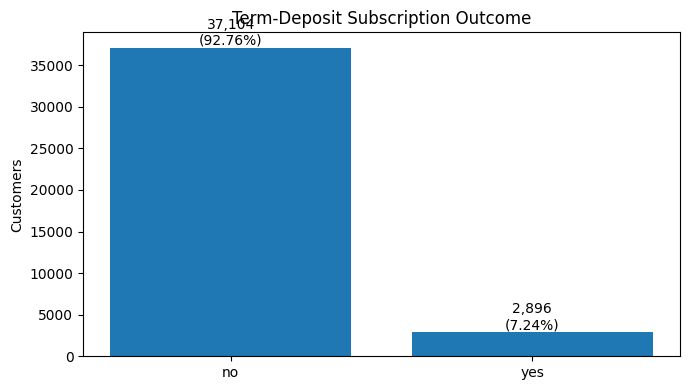

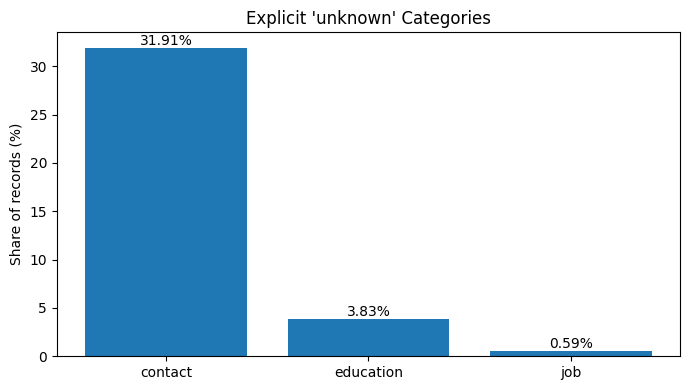

In [4]:
fig,ax=plt.subplots(figsize=(7,4))
p=target.reset_index(names='outcome')
bars=ax.bar(p.outcome,p['count'])
ax.set(title='Term-Deposit Subscription Outcome',ylabel='Customers')
for b,c,pct in zip(bars,p['count'],p['percentage']):
    ax.text(b.get_x()+b.get_width()/2,b.get_height(),f'{c:,}\n({pct:.2f}%)',ha='center',va='bottom')
plt.tight_layout()
plt.show()

up=unknown[unknown.unknown_count>0]
if len(up):
    fig,ax=plt.subplots(figsize=(7,4))
    bars=ax.bar(up.feature,up.unknown_percentage)
    ax.set(title="Explicit 'unknown' Categories",ylabel='Share of records (%)')
    for b,v in zip(bars,up.unknown_percentage):
        ax.text(b.get_x()+b.get_width()/2,b.get_height(),f'{v:.2f}%',ha='center',va='bottom')
    plt.tight_layout()
plt.show()

## 5. Numeric summaries and categorical conversion tables

In [5]:
num_summary=df[numeric].describe().T
num_summary['skewness']=df[numeric].skew()
display(num_summary.round(3))
cat_tables={}
for f in categorical:
    cat_tables[f]=conv(df,f)
for f in ['contact','job','education','month']:
    print(f"\nSubscription outcomes by {f}:")
    display(cat_tables[f].assign(
        subscription_rate_pct=100*cat_tables[f].subscription_rate,
        ci_lower_pct=100*cat_tables[f].ci_lower,
        ci_upper_pct=100*cat_tables[f].ci_upper
    )[[f,'customers','subscribers','subscription_rate_pct','ci_lower_pct','ci_upper_pct']].round(2))

,count,mean,std,min,25%,50%,75%,max,skewness
age,40000.0,40.545,9.642,19.0,33.0,39.0,48.0,95.0,0.436
balance,40000.0,1274.278,2903.770,-8019.0,54.0,407.0,1319.0,102127.0,8.259
day,40000.0,16.017,8.278,1.0,8.0,17.0,21.0,31.0,0.068
duration,40000.0,254.824,259.366,0.0,100.0,175.0,313.0,4918.0,3.165
campaign,40000.0,2.882,3.239,1.0,1.0,2.0,3.0,63.0,4.731



Subscription outcomes by contact:


,contact,customers,subscribers,subscription_rate_pct,ci_lower_pct,ci_upper_pct
0,cellular,24914,2233,8.96,8.61,9.32
1,telephone,2321,166,7.15,6.17,8.27
2,unknown,12765,497,3.89,3.57,4.24



Subscription outcomes by job:


,job,customers,subscribers,subscription_rate_pct,ci_lower_pct,ci_upper_pct
0,student,524,82,15.65,12.79,19.01
1,retired,1437,151,10.51,9.03,12.20
2,unemployed,1104,96,8.70,7.17,10.50
3,management,8166,676,8.28,7.70,8.90
4,self-employed,1414,112,7.92,6.62,9.45
5,admin,4483,351,7.83,7.08,8.65
6,technician,6852,497,7.25,6.66,7.89
7,unknown,235,17,7.23,4.57,11.28
8,entrepreneur,1405,88,6.26,5.11,7.65
9,services,3910,238,6.09,5.38,6.88



Subscription outcomes by education:


,education,customers,subscribers,subscription_rate_pct,ci_lower_pct,ci_upper_pct
0,tertiary,11206,1029,9.18,8.66,9.73
1,secondary,20993,1418,6.75,6.42,7.10
2,unknown,1531,96,6.27,5.16,7.60
3,primary,6270,353,5.63,5.09,6.23



Subscription outcomes by month:


,month,customers,subscribers,subscription_rate_pct,ci_lower_pct,ci_upper_pct
0,oct,80,49,61.25,50.29,71.18
1,mar,258,125,48.45,42.42,54.53
2,apr,2718,451,16.59,15.24,18.04
3,feb,2296,255,11.11,9.89,12.46
4,dec,13,1,7.69,1.37,33.31
5,jun,4734,294,6.21,5.56,6.93
6,nov,3598,220,6.11,5.38,6.95
7,jul,6380,384,6.02,5.46,6.63
8,may,13532,791,5.85,5.46,6.25
9,aug,5215,288,5.52,4.93,6.18


## 6. Ordered contiguous month-labelled blocks

,period_id,month,start_row,end_row,customers,subscribers,subscription_rate,subscription_rate_pct
0,1,may,0,7956,7957,258,0.032,3.242
1,2,jun,7957,12442,4486,201,0.045,4.481
2,3,jul,12443,18822,6380,384,0.060,6.019
3,4,aug,18823,24037,5215,288,0.055,5.523
4,5,oct,24038,24117,80,49,0.612,61.250
5,6,nov,24118,27715,3598,220,0.061,6.115
6,7,dec,27716,27728,13,1,0.077,7.692
7,8,jan,27729,28904,1176,38,0.032,3.231
8,9,feb,28905,31200,2296,255,0.111,11.106
9,10,mar,31201,31458,258,125,0.484,48.450


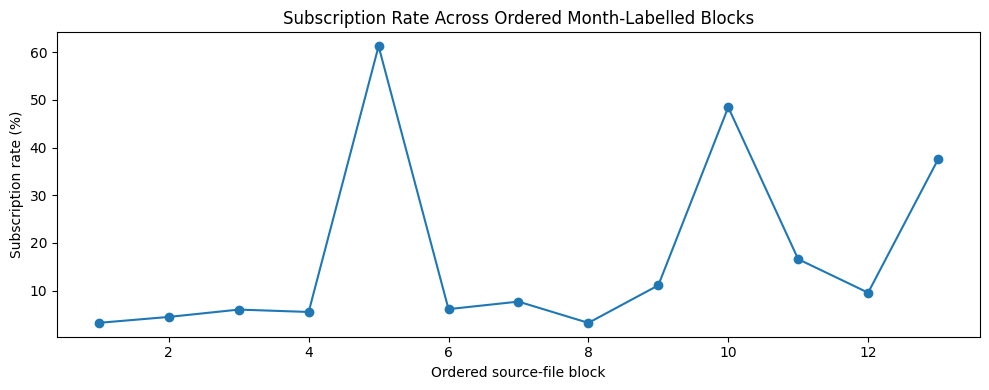

In [6]:
periods=blocks(df)
display(periods.assign(subscription_rate_pct=100*periods.subscription_rate).round(3))
fig,ax=plt.subplots(figsize=(10,4))
ax.plot(periods.period_id,100*periods.subscription_rate,marker='o')
ax.set(
    title='Subscription Rate Across Ordered Month-Labelled Blocks',
    xlabel='Ordered source-file block',
    ylabel='Subscription rate (%)'
)
plt.tight_layout()
plt.show()

## 7. Pre-call associations, duration leakage diagnostic and numeric inter-feature correlations

The deployable association analysis contains only variables available in the pre-call feature set. `duration` is post-call information, so it is excluded from the pre-call Pearson table and figure and evaluated separately as a leakage diagnostic.

Pre-call numeric feature-to-target associations:


,feature,association,variable_type,measure,association_strength
0,campaign,-0.0404,numeric,Pearson r,0.0404
1,balance,0.0302,numeric,Pearson r,0.0302
2,age,-0.0203,numeric,Pearson r,0.0203
3,day,-0.0064,numeric,Pearson r,0.0064


Post-call duration leakage diagnostic:


,feature,association,variable_type,measure,association_strength
0,duration,0.4612,numeric,Pearson r,0.4612


Categorical pre-call feature-to-target associations:


,feature,association,variable_type,measure,association_strength
0,month,0.1945,categorical,Cramer's V,0.1945
1,contact,0.0896,categorical,Cramer's V,0.0896
2,job,0.0589,categorical,Cramer's V,0.0589
3,marital,0.0579,categorical,Cramer's V,0.0579
4,housing,0.0541,categorical,Cramer's V,0.0541
5,education,0.0484,categorical,Cramer's V,0.0484
6,loan,0.0306,categorical,Cramer's V,0.0306
7,default,0.0042,categorical,Cramer's V,0.0042


Pre-call numeric correlation matrix:


,age,balance,day,campaign
age,1.000,0.082,-0.012,0.016
balance,0.082,1.000,0.012,-0.008
day,-0.012,0.012,1.000,0.165
campaign,0.016,-0.008,0.165,1.000


Strongest pre-call numeric feature pairs:


,feature_1,feature_2,correlation,absolute_correlation
0,day,campaign,0.1654,0.1654
1,age,balance,0.0815,0.0815
2,age,campaign,0.0162,0.0162
3,age,day,-0.0117,0.0117
4,balance,day,0.0117,0.0117
5,balance,campaign,-0.0081,0.0081


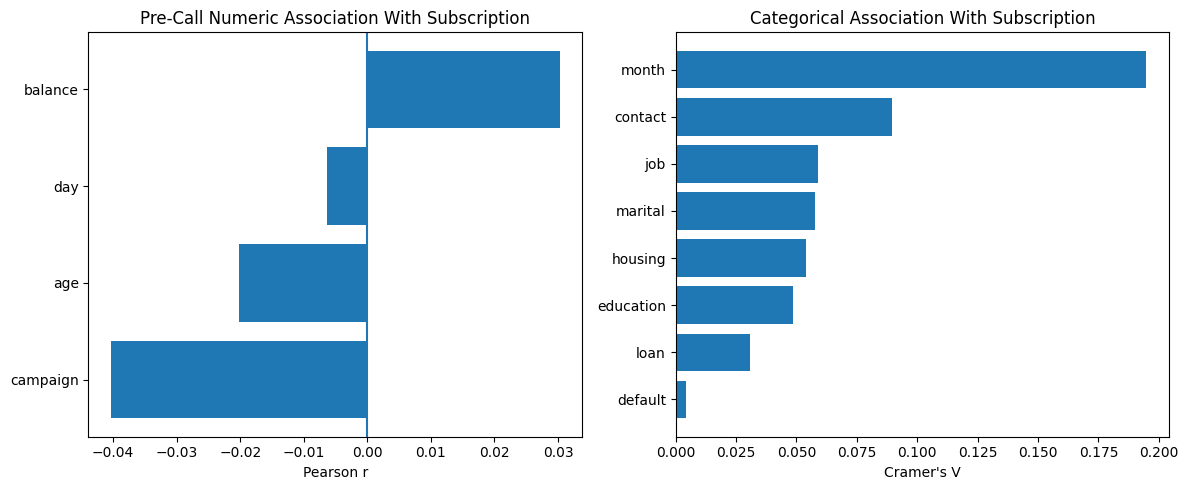

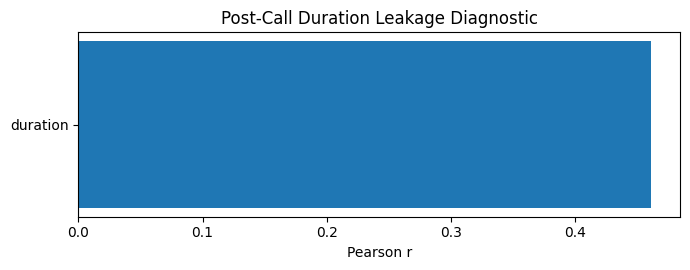

In [7]:
pre_num=[f for f in numeric if f!='duration']
pearson=assoc_num(df,pre_num)
duration_diag=assoc_num(df,['duration'])
cramers=assoc_cat(df,categorical)
all_assoc=pd.concat([pearson,cramers],ignore_index=True)

# Canonical association outputs: deployable/pre-call predictors only.
corr=df[pre_num].corr()
upper=corr.where(np.triu(np.ones(corr.shape),1).astype(bool))
pairs=upper.stack().rename('correlation').reset_index().rename(columns={'level_0':'feature_1','level_1':'feature_2'})
pairs['absolute_correlation']=pairs.correlation.abs()
pairs=pairs.sort_values('absolute_correlation',ascending=False).reset_index(drop=True)
print("Pre-call numeric feature-to-target associations:")
display(pearson.round(4))
print("Post-call duration leakage diagnostic:")
display(duration_diag.round(4))
print("Categorical pre-call feature-to-target associations:")
display(cramers.round(4))
print("Pre-call numeric correlation matrix:")
display(corr.round(3))
print("Strongest pre-call numeric feature pairs:")
display(pairs.head(10).round(4))

fig,axes=plt.subplots(1,2,figsize=(12,5))
q=pearson.sort_values('association')
axes[0].barh(q.feature,q.association)
axes[0].axvline(0)
axes[0].set(title='Pre-Call Numeric Association With Subscription',xlabel='Pearson r')

q=cramers.sort_values('association')
axes[1].barh(q.feature,q.association)
axes[1].set(title='Categorical Association With Subscription',xlabel="Cramer's V")

plt.tight_layout()
plt.show()

# Duration is intentionally isolated so it cannot be mistaken for a deployable predictor.
fig,ax=plt.subplots(figsize=(7,2.8))
q=duration_diag.sort_values('association')
ax.barh(q.feature,q.association)
ax.axvline(0)
ax.set(title='Post-Call Duration Leakage Diagnostic',xlabel='Pearson r')
plt.tight_layout()
plt.show()


## 8. Exploratory higher-conversion population

In [8]:
q3=df.balance.quantile(.75)
seg=(
    df.contact.astype(str).str.lower().eq('cellular')
    & (
        df.job.astype(str).str.lower().eq('retired')
        | df.age.ge(71)
        | df.balance.ge(q3)
    )
)

seg_n=int(seg.sum())
seg_y=int(df.loc[seg,'y_binary'].sum())

segment=pd.DataFrame([{
    'balance_q3':q3,
    'age_threshold':71,
    'customers':seg_n,
    'subscribers':seg_y,
    'subscription_rate':seg_y/seg_n,
    'full_rate':rate,
    'relative_uplift':(seg_y/seg_n)/rate-1,
    'status':'exploratory data-derived rule; not causal or pre-registered'
}])

display(segment.round(4))


,balance_q3,age_threshold,customers,subscribers,subscription_rate,full_rate,relative_uplift,status
0,1319.0,71,6774,778,0.1149,0.0724,0.5863,exploratory data-derived rule; not causal or p...


## 9. Consolidated EDA summary

In [9]:
summary=pd.DataFrame({
    'metric':[
        'rows','subscribers','subscription_rate','majority_accuracy','exact_duplicate_rows',
        'pseudo_repeat_rows','pseudo_repeat_rate','largest_unknown_feature','largest_unknown_rate',
        'strongest_pre_call_numeric_feature','strongest_pre_call_numeric_association',
        'duration_post_call_pearson_diagnostic',
        'strongest_categorical_feature','strongest_categorical_association',
        'strongest_numeric_pair','strongest_numeric_pair_correlation',
        'ordered_blocks','segment_customers','segment_subscribers','segment_rate'
    ],
    'value':[
        n,yes,rate,majority,exact_dup,repeat_rows,repeat_rows/n,
        unknown.iloc[0].feature,unknown.iloc[0].unknown_percentage/100,
        pearson.iloc[0].feature,pearson.iloc[0].association,
        duration_diag.iloc[0].association,
        cramers.iloc[0].feature,cramers.iloc[0].association,
        f"{pairs.iloc[0].feature_1} ↔ {pairs.iloc[0].feature_2}",
        pairs.iloc[0].correlation,len(periods),seg_n,seg_y,seg_y/seg_n
    ]
})

display(summary)


,metric,value
0,rows,40000
1,subscribers,2896
2,subscription_rate,0.0724
3,majority_accuracy,0.9276
4,exact_duplicate_rows,0
5,pseudo_repeat_rows,6095
6,pseudo_repeat_rate,0.152375
7,largest_unknown_feature,contact
8,largest_unknown_rate,0.319125
9,strongest_pre_call_numeric_feature,campaign
